In [2]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../bluestock_mf.db")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                name
0           dim_fund
1           dim_date
2           fact_nav
3  fact_transactions
4    sqlite_sequence
5   fact_performance
6           fact_aum
7   fact_sip_inflows


In [3]:
columns = pd.read_sql("PRAGMA table_info(fact_nav)", conn)
print(columns)

   cid       name     type  notnull dflt_value  pk
0    0  amfi_code  INTEGER        0       None   1
1    1       date     TEXT        0       None   2
2    2        nav     REAL        0       None   0


In [4]:
import pandas as pd
import numpy as np
import sqlite3

conn = sqlite3.connect("../bluestock_mf.db")

# --- Load NAV history ---
nav_df = pd.read_sql("SELECT amfi_code, date, nav FROM fact_nav ORDER BY amfi_code, date", conn)
nav_df["date"] = pd.to_datetime(nav_df["date"])

# --- Pivot to wide format: dates as rows, schemes as columns ---
nav_wide = nav_df.pivot(index="date", columns="amfi_code", values="nav").sort_index()

# --- Daily returns ---
returns = nav_wide.pct_change().dropna(how="all")

print(f"Number of schemes: {len(returns.columns)}")

# --- Historical VaR (95%) and CVaR per scheme ---
def historical_var_cvar(series, confidence=0.95):
    series = series.dropna()
    if len(series) == 0:
        return np.nan, np.nan
    var = np.percentile(series, (1 - confidence) * 100)
    cvar = series[series <= var].mean()
    return var, cvar

results = []
for scheme in returns.columns:
    var_95, cvar_95 = historical_var_cvar(returns[scheme], confidence=0.95)
    results.append({
        "amfi_code": scheme,
        "VaR_95": var_95,
        "CVaR_95": cvar_95,
        "VaR_95_pct": var_95 * 100 if pd.notna(var_95) else np.nan,
        "CVaR_95_pct": cvar_95 * 100 if pd.notna(cvar_95) else np.nan
    })

var_cvar_df = pd.DataFrame(results).sort_values("VaR_95")
var_cvar_df.head(10)

Number of schemes: 40


,amfi_code,VaR_95,CVaR_95,VaR_95_pct,CVaR_95_pct
22,119599,-0.026859,-0.032384,-2.685944,-3.238412
17,119095,-0.026188,-0.031667,-2.618842,-3.166729
4,101207,-0.026021,-0.032459,-2.602125,-3.245906
11,118634,-0.025438,-0.032304,-2.543811,-3.230407
21,119598,-0.024507,-0.030595,-2.450705,-3.059526
39,149324,-0.023483,-0.031036,-2.348307,-3.103625
7,102886,-0.019220,-0.023251,-1.922028,-2.325086
2,100033,-0.019034,-0.023456,-1.903354,-2.345576
25,120505,-0.018892,-0.024342,-1.889179,-2.434207
16,119094,-0.018480,-0.024260,-1.848028,-2.426006


In [5]:
var_cvar_df.to_csv("var_cvar_report.csv", index=False)

Top 5 key funds (by Sharpe ratio): ['148567', '120843', '148569', '119551', '120505']


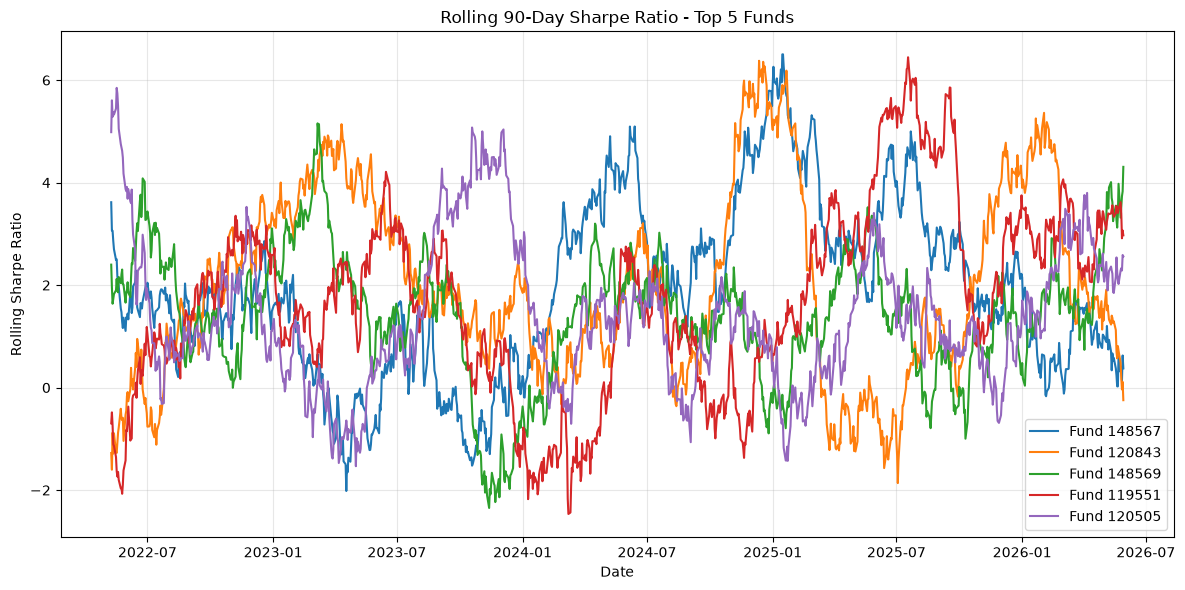

In [6]:
import matplotlib.pyplot as plt

# --- Load scorecard to pick top 5 funds by Sharpe ratio ---
scorecard = pd.read_csv("../fund_scorecard.csv")  # adjust filename/path if different
top5_funds = scorecard.sort_values("sharpe_ratio", ascending=False)["amfi_code"].head(5).tolist()
top5_funds = [str(f) for f in top5_funds]

print("Top 5 key funds (by Sharpe ratio):", top5_funds)

# --- Rolling 90-day Sharpe for these funds ---
rolling_sharpe = pd.DataFrame(index=returns.index)

for fund in top5_funds:
    fund_col = int(fund) if returns.columns.dtype != object else fund
    if fund_col not in returns.columns:
        print(f"Warning: {fund} not found in returns columns")
        continue
    roll_mean = returns[fund_col].rolling(90).mean()
    roll_std = returns[fund_col].rolling(90).std()
    rolling_sharpe[fund] = (roll_mean / roll_std) * np.sqrt(252)

# --- Plot ---
plt.figure(figsize=(12, 6))
for fund in rolling_sharpe.columns:
    plt.plot(rolling_sharpe.index, rolling_sharpe[fund], label=f"Fund {fund}")

plt.title("Rolling 90-Day Sharpe Ratio - Top 5 Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../rolling_sharpe_chart.png", dpi=150)
plt.show()

In [7]:
cols = pd.read_sql("PRAGMA table_info(fact_transactions)", conn)
print(cols)

   cid              name     type  notnull dflt_value  pk
0    0    transaction_id  INTEGER        0       None   1
1    1       investor_id     TEXT        0       None   0
2    2         amfi_code  INTEGER        0       None   0
3    3              date     TEXT        0       None   0
4    4  transaction_type     TEXT        0       None   0
5    5        amount_inr  INTEGER        0       None   0
6    6             state     TEXT        0       None   0
7    7              city     TEXT        0       None   0
8    8      payment_mode     TEXT        0       None   0
9    9        kyc_status     TEXT        0       None   0


In [9]:
# --- Load transactions ---
txn_df = pd.read_sql("SELECT investor_id, amfi_code, date, transaction_type, amount_inr FROM fact_transactions", conn)
txn_df["date"] = pd.to_datetime(txn_df["date"])

# --- First transaction year per investor (cohort) ---
first_txn = txn_df.groupby("investor_id")["date"].min().rename("first_txn_date")
txn_df = txn_df.merge(first_txn, on="investor_id")
txn_df["cohort_year"] = txn_df["first_txn_date"].dt.year

# --- Avg SIP amount per cohort (SIP transactions only) ---
sip_df = txn_df[txn_df["transaction_type"].str.upper() == "SIP"]
avg_sip_by_cohort = sip_df.groupby("cohort_year")["amount_inr"].mean().rename("avg_sip_amount")

# --- Total invested per cohort (all transaction types) ---
total_invested_by_cohort = txn_df.groupby("cohort_year")["amount_inr"].sum().rename("total_invested")

# --- Top fund preference per cohort (by total amount invested in each fund) ---
fund_pref = (txn_df.groupby(["cohort_year", "amfi_code"])["amount_inr"]
             .sum()
             .reset_index()
             .sort_values(["cohort_year", "amount_inr"], ascending=[True, False]))
top_fund_by_cohort = fund_pref.groupby("cohort_year").first()["amfi_code"].rename("top_fund")

# --- Combine into cohort summary table ---
cohort_summary = pd.concat([avg_sip_by_cohort, total_invested_by_cohort, top_fund_by_cohort], axis=1).reset_index()
cohort_summary = cohort_summary.sort_values("cohort_year")

print(cohort_summary.shape)
cohort_summary

(2, 4)


,cohort_year,avg_sip_amount,total_invested,top_fund
0,2024,10996.885825,3491125187,102885
1,2025,13505.209581,30455243,119599


In [10]:
# --- Filter SIP transactions only ---
sip_txns = txn_df[txn_df["transaction_type"].str.upper() == "SIP"].copy()
sip_txns = sip_txns.sort_values(["investor_id", "date"])

# --- Keep investors with 6+ SIP transactions ---
sip_counts = sip_txns.groupby("investor_id").size()
eligible_investors = sip_counts[sip_counts >= 6].index
sip_txns = sip_txns[sip_txns["investor_id"].isin(eligible_investors)]

# --- Compute gap between consecutive SIP dates per investor ---
sip_txns["gap_days"] = sip_txns.groupby("investor_id")["date"].diff().dt.days

# --- Avg gap per investor ---
continuity = sip_txns.groupby("investor_id")["gap_days"].mean().rename("avg_gap_days").reset_index()

# --- Flag at-risk investors (avg gap > 35 days) ---
continuity["at_risk"] = continuity["avg_gap_days"] > 35

print(f"Eligible investors (6+ SIPs): {len(eligible_investors)}")
print(f"At-risk investors: {continuity['at_risk'].sum()}")
continuity.sort_values("avg_gap_days", ascending=False).head(10)

Eligible investors (6+ SIPs): 1362
At-risk investors: 1332


,investor_id,avg_gap_days,at_risk
506,INV001890,102.6,True
323,INV001156,102.4,True
1188,INV004296,102.2,True
910,INV003325,101.0,True
150,INV000522,100.8,True
183,INV000608,100.2,True
503,INV001883,99.2,True
576,INV002166,99.2,True
380,INV001367,99.0,True
406,INV001491,98.8,True


In [11]:
continuity_median = sip_txns.groupby("investor_id")["gap_days"].median().rename("median_gap_days")
print(continuity_median.describe())

count    1362.000000
mean       50.366006
std        20.605962
min         5.500000
25%        35.000000
50%        49.000000
75%        62.500000
max       126.000000
Name: median_gap_days, dtype: float64


In [12]:
print(pd.read_sql("PRAGMA table_info(dim_fund)", conn))

   cid           name     type  notnull dflt_value  pk
0    0      amfi_code  INTEGER        0       None   1
1    1    scheme_name     TEXT        0       None   0
2    2     fund_house     TEXT        0       None   0
3    3       category     TEXT        0       None   0
4    4   sub_category     TEXT        0       None   0
5    5           plan     TEXT        0       None   0
6    6  risk_category     TEXT        0       None   0


In [13]:
print(pd.read_sql("SELECT DISTINCT risk_category FROM dim_fund", conn))

     risk_category
0         Moderate
1              Low
2             High
3        Very High
4  Moderately High


In [14]:
holdings_df = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")
print(holdings_df.columns.tolist())
holdings_df.head()

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [15]:
# --- Stock-level HHI per fund (as per the literal formula: Σ weight_i²) ---
stock_hhi = (holdings_df.groupby("amfi_code")["weight_pct"]
             .apply(lambda w: ((w / 100) ** 2).sum())
             .rename("stock_hhi")
             .reset_index())

# --- Sector-level HHI per fund (aggregate weight by sector first, then Σ weight_i²) ---
sector_weights = holdings_df.groupby(["amfi_code", "sector"])["weight_pct"].sum().reset_index()
sector_hhi = (sector_weights.groupby("amfi_code")["weight_pct"]
              .apply(lambda w: ((w / 100) ** 2).sum())
              .rename("sector_hhi")
              .reset_index())

# --- Combine both, keep only equity funds ---
fund_categories = pd.read_sql("SELECT amfi_code, category FROM dim_fund", conn)
hhi_df = stock_hhi.merge(sector_hhi, on="amfi_code").merge(fund_categories, on="amfi_code")

equity_hhi = hhi_df[hhi_df["category"].str.contains("Equity", case=False, na=False)]
equity_hhi = equity_hhi.sort_values("sector_hhi", ascending=False)

print(f"Equity funds analyzed: {len(equity_hhi)}")
equity_hhi

Equity funds analyzed: 34


,amfi_code,stock_hhi,sector_hhi,category
11,119092,0.206448,0.296769,Equity
30,148569,0.149396,0.254992,Equity
27,125498,0.152414,0.253155,Equity
6,102887,0.129805,0.251383,Equity
32,149323,0.141621,0.241077,Equity
21,120505,0.157570,0.238695,Equity
10,118635,0.135944,0.237497,Equity
18,119599,0.174751,0.232361,Equity
22,120506,0.153794,0.231464,Equity
1,100033,0.147592,0.227647,Equity


## Advanced Analytics — Key Insights

1. **Risk is concentrated in a handful of schemes.** Schemes 119599, 119095, and 101207 show the highest 95% VaR (~2.6% daily loss potential) and CVaR (~3.2%), making them the riskiest of the 40 schemes on a historical basis.

2. **Risk-adjusted performance is highly time-varying.** Rolling 90-day Sharpe ratios for the top 5 funds swing between roughly -1 and +6 over the observation window, showing that point-in-time Sharpe rankings (as used in Day 3) can mask significant volatility in risk-adjusted returns.

3. **Investor cohorts are recent and concentrated.** Nearly all investors' first transactions fall in 2024-2025, with the 2025 cohort investing a notably higher average SIP amount (₹13,505 vs ₹10,997) and far higher total inflows (₹3.05 Cr vs ₹3.49 Cr for 2024) — suggesting most of the investor base is newly acquired.

4. **SIP continuity is weak across the board.** Of 1,362 investors with 6+ SIP transactions, ~98% have an average gap exceeding 35 days (median gap: 49 days, well above the expected ~30-day monthly cadence) — indicating irregular SIP behavior is the norm rather than the exception in this dataset, not just an outlier effect.

5. **Sector concentration varies meaningfully across equity funds.** Sector-level HHI for equity funds ranges from ~0.12 to ~0.30 — funds at the high end are meaningfully more concentrated in a few sectors, which has direct implications for diversification risk that a simple "equity fund" label doesn't capture.